# Tennis Prediction Engine

**Predicting ATP match winners from 884,030 matches (1968-2024), without leaking the future.**

Author: Dhruv Dhariwal

---

This notebook is a *narrated driver* over the `tennis_engine` package in `src/`.
Every function called here is the same code that runs in production via the CLI
and that is covered by the test suite -- there is no second, notebook-only
implementation that can drift out of sync.

## The three properties the engine is built around

**1. Leak-proof.** Matches are replayed in the order they were played. For each
match the builder *reads* state, *emits* a feature row, and only then *updates*
Elo, head-to-head, form and serve statistics. No feature can depend on the match
it describes.

**2. Order-invariant.** `P(A beats B)` must equal `1 - P(B beats A)`. Every
feature is either antisymmetric (a difference, which negates when the players
swap) or symmetric (surface, best-of, tier). Swapping players is therefore a sign
flip, and the final prediction is symmetrized so the identity holds *exactly*,
not approximately.

**3. Honestly evaluated.** Three chronological splits. Ratings warm up on
1968-1990, the model trains on 1991-2022, hyperparameters and early stopping use
2023, and **2024 is not touched until the final evaluation.**

In [1]:
import json
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The package lives in src/ and is importable without installation.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from tennis_engine import evaluate, pipeline, reporting
from tennis_engine.config import Config, Paths
from tennis_engine.data import load_player_directory, prepare_matches
from tennis_engine.features import FEATURE_INDEX, FEATURE_NAMES, FLIP_SIGN
from tennis_engine.rankings import build_ranking_lookup, to_day_ordinal

logging.basicConfig(level=logging.INFO, format="%(levelname)-7s %(message)s", force=True)
pd.set_option("display.width", 150)

cfg = Config(paths=Paths(base_dir=PROJECT_ROOT, artifacts_dir=PROJECT_ROOT / "artifacts"))
print("Project root   :", cfg.paths.base_dir.name)
print("Features       :", len(FEATURE_NAMES))
print("Split          : warmup %d-%d | train %d-%d | val %s | test %s" % (
    min(cfg.split.warmup_years), max(cfg.split.warmup_years),
    min(cfg.split.train_years), max(cfg.split.train_years),
    list(cfg.split.val_years), list(cfg.split.test_years)))

Project root   : Tennis Prediction Engine
Features       : 33
Split          : warmup 1968-1990 | train 1991-2022 | val [2023] | test [2024]


---
## 1. Load and clean

`prepare_matches` loads the ATP main tour, Challenger/qualifying and Futures
files, then removes what cannot be learned from and what must not be seen.

Two cleaning decisions are worth calling out, because both were bugs in the
first version of this project:

- **Outcome columns are dropped by an explicit list, not a regex.** The old
  filter was `score|min|retired|walkover|wo|after|next|post`. The `wo`
  alternative matches "**Wo**n" case-insensitively, so it silently deleted
  `w_1stWon`, `w_2ndWon`, `l_1stWon` and `l_2ndWon` -- the four columns the
  service-points-won feature is computed from. That feature was identically zero
  for all 3.2 million rows and nobody noticed.
- **Unknown surfaces stay unknown.** They used to be rewritten to `Hard`, which
  fabricated hard-court Elo history for every unlabelled match.

In [2]:
matches = prepare_matches(cfg.paths.base_dir, cfg.split.all_years())

print(f"{len(matches):,} matches, {matches.tourney_date.min().date()} -> {matches.tourney_date.max().date()}")
display(matches.groupby("tier").agg(
    matches=("winner_id", "size"),
    first=("tourney_date", "min"),
    last=("tourney_date", "max"),
))
display(matches.surface.value_counts().rename("matches").to_frame())

# The columns that make the fixed serve feature possible:
assert {"w_1stWon", "w_2ndWon", "l_1stWon", "l_2ndWon"} <= set(matches.columns)
assert "score" not in matches.columns and "winner_rank" not in matches.columns
print("\nLeakage audit: outcome columns removed, box-score columns retained.")

INFO    Loaded 884,030 matches for 1968-2024 (dropped: 32,611 incomplete, 0 invalid, 7 self-matches, 0 duplicates; leaky columns removed: ['score', 'minutes', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'])


884,030 matches, 1967-12-28 -> 2024-12-18


,matches,first,last
tier,,,
atp,189669,1967-12-28,2024-12-18
challenger,215503,1978-01-08,2024-11-25
futures,478858,1990-12-29,2024-12-16


,matches
surface,
Clay,418810
Hard,379870
Carpet,47823
Grass,34611
Unknown,2916



Leakage audit: outcome columns removed, box-score columns retained.


---
## 2. Point-in-time ATP rankings

3.3 million weekly ranking snapshots are collapsed into per-player sorted numpy
arrays. Looking up "what was this player ranked immediately before date D" is
then a binary search -- `O(log n)` instead of a scan over the whole table.

The lookup is strictly *as-of*: it can only ever return a snapshot dated on or
before the match. Rankings are published on Mondays and already reflect the
previous week's results, so a snapshot dated the same day a tournament starts is
legitimate pre-match information.

In [3]:
rankings = build_ranking_lookup(cfg.paths.base_dir)
print(f"{rankings.n_rows:,} snapshots across {len(rankings):,} players")

# Demonstrate the as-of semantics on one player across one ranking change.
pid = 104925  # Novak Djokovic
for date in ["2015-06-01", "2018-06-01", "2021-06-01", "2024-06-03"]:
    rank, points, ranked = rankings.get(pid, int(to_day_ordinal(pd.Timestamp(date))))
    print(f"  {date}: rank {int(rank):>5}  points {int(points):>6}  ranked={ranked}")

# A date before the player's first ever ranking must report 'unranked'.
rank, points, ranked = rankings.get(pid, int(to_day_ordinal(pd.Timestamp('1990-01-01'))))
print(f"  1990-01-01: rank {int(rank)} points {int(points)} ranked={ranked}  <- correctly unranked")

INFO    Ranking lookup: 3,292,228 snapshots across 16,474 players (1973-08-27 - 2024-12-30)


3,292,228 snapshots across 16,474 players
  2015-06-01: rank     1  points  13845  ranked=True
  2018-06-01: rank    22  points   1665  ranked=True
  2021-06-01: rank     1  points  11313  ranked=True
  2024-06-03: rank     1  points   9960  ranked=True
  1990-01-01: rank 2500 points 0 ranked=False  <- correctly unranked


---
## 3. Build features chronologically

One pass over all 884k matches. The warm-up seasons update ratings without
emitting rows, so the model never trains on the pre-1991 era (which has almost
no box scores) but ratings entering 1991 are not cold-started at 1500.

**Training rows are mirrored, evaluation rows are not.** Each training match
contributes both orientations, which makes the training distribution exactly
symmetric. Each *evaluation* match contributes exactly one randomly-oriented row,
so the reported match counts and metrics describe real matches rather than each
match counted twice.

This cell is the expensive one -- roughly 5-8 minutes for the full history.

In [4]:
%time splits, builder = pipeline.build_splits(cfg)

print()
print(f"train : {len(splits.train):>9,} rows  ({len(splits.train)//2:,} matches, both orientations)")
print(f"val   : {len(splits.val):>9,} rows  (2023)")
print(f"test  : {len(splits.test):>9,} rows  (2024)")
print(f"players tracked: {splits.n_players:,}")

INFO    Loaded 884,030 matches for 1968-2024 (dropped: 32,611 incomplete, 0 invalid, 7 self-matches, 0 duplicates; leaky columns removed: ['score', 'minutes', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'])


INFO    Ranking lookup: 3,292,228 snapshots across 16,474 players (1973-08-27 - 2024-12-30)


INFO    Player directory: 65,989 entries


INFO    Built 0 rows from 105,974 matches (mirror=False, emit=False); 5,382 players tracked, 78,165 h2h pairs


INFO    Built 1,433,428 rows from 716,714 matches (mirror=True, emit=True); 27,082 players tracked, 660,834 h2h pairs


INFO    Built 29,989 rows from 29,989 matches (mirror=False, emit=True); 27,725 players tracked, 686,069 h2h pairs


INFO    Built 31,339 rows from 31,339 matches (mirror=False, emit=True); 28,451 players tracked, 712,282 h2h pairs


INFO    Splits built in 105.1s -- warmup 105,974 matches | train 1,433,428 rows | val 29,989 rows | test 31,339 rows


CPU times: total: 1min 27s
Wall time: 1min 45s

train : 1,433,428 rows  (716,714 matches, both orientations)
val   :    29,989 rows  (2023)
test  :    31,339 rows  (2024)
players tracked: 28,451


### 3a. Leakage and symmetry audits

These are assertions, not prose. If the feature builder ever regresses, this cell
raises rather than quietly producing a better-looking number.

One thing the audit surfaces immediately: `surface_is_unknown` is constant across
1991-2022, because every match in the training window has a labelled surface --
the 2,858 unlabelled ones all sit in the pre-1991 warm-up era. There are 51 in
2023-24, and they correctly arrive with all four real surface flags at zero, so
the model falls back on surface-agnostic signal for them instead of being told
they were played on hard court.

In [5]:
X = splits.train.X

# (1) Antisymmetry: mirrored training rows are exact negations on the diff block
#     and identical on the symmetric block.
forward, mirrored = X[0::2], X[1::2]
assert np.allclose(mirrored, forward * FLIP_SIGN, equal_nan=True)
print("PASS  mirrored rows are exact sign-flips")

# (2) One-hot surface encoding really is one-hot (this used to be NaN-filled).
surface_cols = [FEATURE_INDEX[c] for c in FEATURE_NAMES if c.startswith("surface_is_")]
block = X[:, surface_cols]
assert not np.isnan(block).any() and np.array_equal(block.sum(1), np.ones(len(block)))
print("PASS  surface one-hot has no NaNs and sums to 1")

# (3) No feature is constant -- a constant feature is dead code, which is exactly
#     what silently happened to srv_winrate_diff in v1.
dead = []
for name in FEATURE_NAMES:
    col = X[:, FEATURE_INDEX[name]]
    finite = col[np.isfinite(col)]
    if len(finite) == 0 or np.allclose(finite, finite[0]):
        dead.append(name)

# A *surface* flag may legitimately be constant: a category can simply not occur
# in this window. Everything else being constant is a bug.
unexpected = [n for n in dead if not n.startswith("surface_is_")]
assert not unexpected, f"constant (dead) features: {unexpected}"
print("PASS  every substantive feature varies, srv_winrate_diff included")
if dead:
    print(f"      note: {', '.join(dead)} constant in this training window")

# (4) Chronology: evaluation rows never precede training rows.
assert splits.train.date.max() < splits.val.date.min() < splits.test.date.min()
print("PASS  train < val < test in time, with no overlap")

# (5) Missingness is preserved rather than coerced to zero.
missing = pd.Series(np.isnan(X).mean(axis=0) * 100, index=list(FEATURE_NAMES))
display(missing[missing > 0].sort_values(ascending=False).round(2)
        .rename("% missing").to_frame())

PASS  mirrored rows are exact sign-flips
PASS  surface one-hot has no NaNs and sums to 1


PASS  every substantive feature varies, srv_winrate_diff included
      note: surface_is_unknown constant in this training window
PASS  train < val < test in time, with no overlap


,% missing
bp_save_rate_diff,64.75
ace_rate_diff,64.70
df_rate_diff,64.70
srv_winrate_diff,64.70
ret_winrate_diff,64.69
height_diff,53.90
lefty_diff,20.32
surf_winrate_diff,5.10
form_diff,2.93
career_winrate_diff,2.93


---
## 4. Train

XGBoost with early stopping on the **2023 validation season**.

The original version early-stopped on the 2024 test set. That is model selection
on the test data: the number of trees was chosen to minimise test loss, so the
reported 2024 metrics were optimistic by construction. Moving early stopping to a
dedicated validation season is the single most important methodological fix here,
and it is the reason the headline numbers in this notebook can be quoted honestly.

[0]	train-logloss:0.68359	train-auc:0.75445	val-logloss:0.68365	val-auc:0.75038


[100]	train-logloss:0.57018	train-auc:0.77049	val-logloss:0.57276	val-auc:0.76795


[200]	train-logloss:0.56681	train-auc:0.77355	val-logloss:0.57110	val-auc:0.76959


[300]	train-logloss:0.56488	train-auc:0.77543	val-logloss:0.57053	val-auc:0.77019


[400]	train-logloss:0.56343	train-auc:0.77681	val-logloss:0.57033	val-auc:0.77037


[500]	train-logloss:0.56210	train-auc:0.77808	val-logloss:0.57031	val-auc:0.77039


[600]	train-logloss:0.56091	train-auc:0.77925	val-logloss:0.57024	val-auc:0.77044


[652]	train-logloss:0.56033	train-auc:0.77979	val-logloss:0.57031	val-auc:0.77036


INFO    Best iteration 552 (val logloss 0.57023)


CPU times: total: 20min
Wall time: 11min 55s


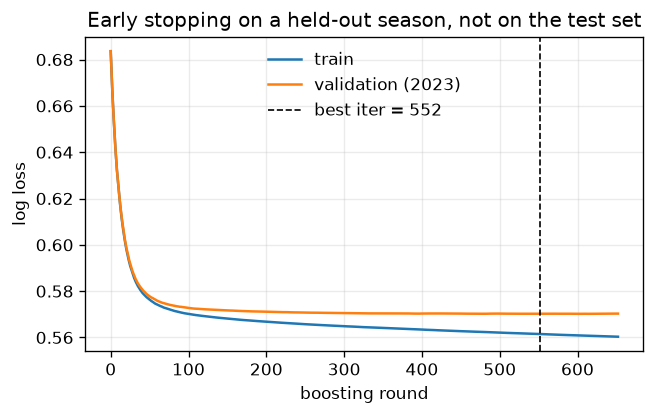

In [6]:
%time booster, history = pipeline.train_model(cfg, splits)

fig, ax = plt.subplots(figsize=(6, 3.4), dpi=120)
ax.plot(history["train"]["logloss"], label="train")
ax.plot(history["val"]["logloss"], label="validation (2023)")
ax.axvline(booster.best_iteration, color="k", ls="--", lw=1,
           label=f"best iter = {booster.best_iteration}")
ax.set_xlabel("boosting round"); ax.set_ylabel("log loss")
ax.set_title("Early stopping on a held-out season, not on the test set")
ax.legend(frameon=False); ax.grid(alpha=.25)
plt.show()

---
## 5. Evaluate on 2024

`evaluate_all` fits the probability calibrator on the validation season, then
scores the untouched test season. It also runs the baselines that any learned
model has to beat before it is worth anything:

- **Elo (global)** and **Elo (surface-blended)** -- closed-form win probability
  from the ratings alone.
- **ATP rank** -- pick the better-ranked player.
- **Coin flip.**

In [7]:
metrics, calibrator = pipeline.evaluate_all(cfg, splits, booster)

rows = []
for name, block in [("XGBoost (calibrated)", metrics["test"]),
                    ("XGBoost (uncalibrated)", metrics["test_uncalibrated"]),
                    *[(f"baseline: {k}", v) for k, v in metrics["test_baselines"].items()]]:
    rows.append({
        "model": name,
        "accuracy": block.get("accuracy"),
        "auc": block.get("auc"),
        "log_loss": block.get("log_loss"),
        "brier": block.get("brier"),
        "ece": block.get("ece"),
    })
display(pd.DataFrame(rows).set_index("model").round(4))

INFO    Calibrator selected: isotonic (val log loss by method: {'isotonic': 0.56922, 'temperature': 0.570195, 'identity': 0.570249})


INFO    Wrote 4 figures to artifacts\figures


,accuracy,auc,log_loss,brier,ece
model,,,,,
XGBoost (calibrated),0.6995,0.7733,0.5680,0.1936,0.0082
XGBoost (uncalibrated),0.6996,0.7734,0.5678,0.1936,0.0095
baseline: elo_global,0.6735,0.7399,0.5996,0.2067,0.0158
baseline: elo_surface_blended,0.6724,0.7365,0.6035,0.2083,0.0246
baseline: atp_rank,0.6732,0.7316,NaN,NaN,NaN
baseline: bookmaker_free_coinflip,0.5000,0.5000,0.6931,0.2500,NaN


### 5a. Where the accuracy actually comes from

A single headline accuracy over a corpus that is 55% Futures is misleading: those
draws contain enormous ranking mismatches and are easy to call. Tour-level
matches are much harder and are what the number would be judged on.

In [8]:
display(pd.DataFrame(metrics["test_slices"]).T[["n", "accuracy", "auc", "log_loss", "brier"]].round(4))

,n,accuracy,auc,log_loss,brier
futures,17611.0,0.7250,0.7991,0.5441,0.1829
challenger,10755.0,0.6639,0.7306,0.6025,0.2089
atp_main_tour,2973.0,0.6778,0.7501,0.5853,0.2017
min_prior_matches_ge_0,31339.0,0.6995,0.7733,0.5680,0.1936
min_prior_matches_ge_10,27134.0,0.6839,0.7530,0.5868,0.2015
min_prior_matches_ge_25,23521.0,0.6748,0.7416,0.5964,0.2056
min_prior_matches_ge_50,19408.0,0.6662,0.7310,0.6048,0.2092


### 5b. Calibration

Accuracy alone says nothing about whether a stated 70% actually wins 70% of the
time. The calibrator is fitted on the validation season and is chosen from
identity / temperature scaling / symmetric isotonic by validation log loss.

Both non-trivial calibrators are **symmetry preserving** by construction --
temperature scaling because `logit(1-p) = -logit(p)`, and the isotonic variant
because it is fitted on the symmetry-augmented sample and averaged in both
directions. An off-the-shelf calibrator would silently break `P(A) = 1 - P(B)`.

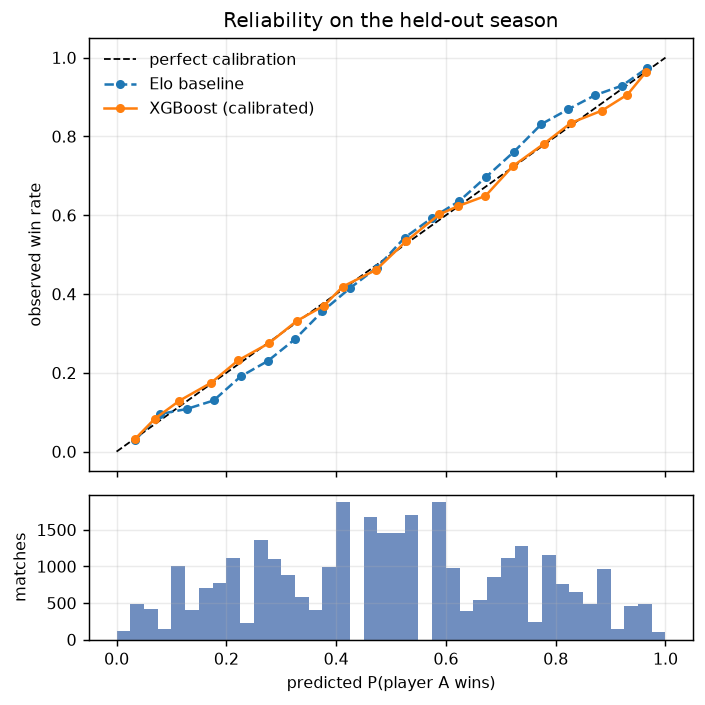

calibrator selected : isotonic
validation log loss by method: {'isotonic': 0.56922, 'temperature': 0.570195, 'identity': 0.570249}
test ECE: 0.0082 (uncalibrated 0.0095)


In [9]:
predict = pipeline.make_predictor(booster, calibrator)
p_test = predict(splits.test.X)

reporting.plot_reliability(
    splits.test.y, p_test,
    evaluate.elo_probability(splits.test.X, "blend_elo_diff"),
    cfg.paths.figures_dir / "reliability.png",
)
from IPython.display import Image
display(Image(str(cfg.paths.figures_dir / "reliability.png")))

print("calibrator selected :", metrics["model"]["calibrator"])
print("validation log loss by method:", metrics["model"]["calibration_val_logloss"])
print(f"test ECE: {metrics['test']['ece']:.4f} "
      f"(uncalibrated {metrics['test_uncalibrated']['ece']:.4f})")

### 5c. Order-invariance

The original notebook asserted `mean |p(A,B) - (1 - p(B,A))| < 0.02` and called
that order-invariant. It is a tolerance, not a guarantee -- and it says nothing
about the worst case.

Here the prediction is explicitly symmetrized, `p = ½·(p(A,B) + 1 - p(B,A))`, so
the identity holds to floating-point precision for **every** match, not on
average.

In [10]:
sym = evaluate.symmetry_error(predict, splits.test.X)
for k, v in sym.items():
    print(f"  {k:<18s} {v:.3e}")
assert sym["max_abs_error"] < 1e-9, "order invariance broken"
print("\nPASS  P(A beats B) + P(B beats A) = 1 exactly, for all 2024 matches")

  mean_abs_error     2.025e-17
  max_abs_error      1.110e-16
  p99_abs_error      1.110e-16

PASS  P(A beats B) + P(B beats A) = 1 exactly, for all 2024 matches


### 5d. What the model is using

,% of total gain
blend_elo_diff,16.941
elo_diff,16.079
elo_expectation_diff,14.181
is_ranked_diff,8.940
log_points_diff,7.042
log_rank_diff,6.157
rank_diff,3.516
surf_elo_diff,3.036
workload_diff,2.770
log_days_since_diff,2.681


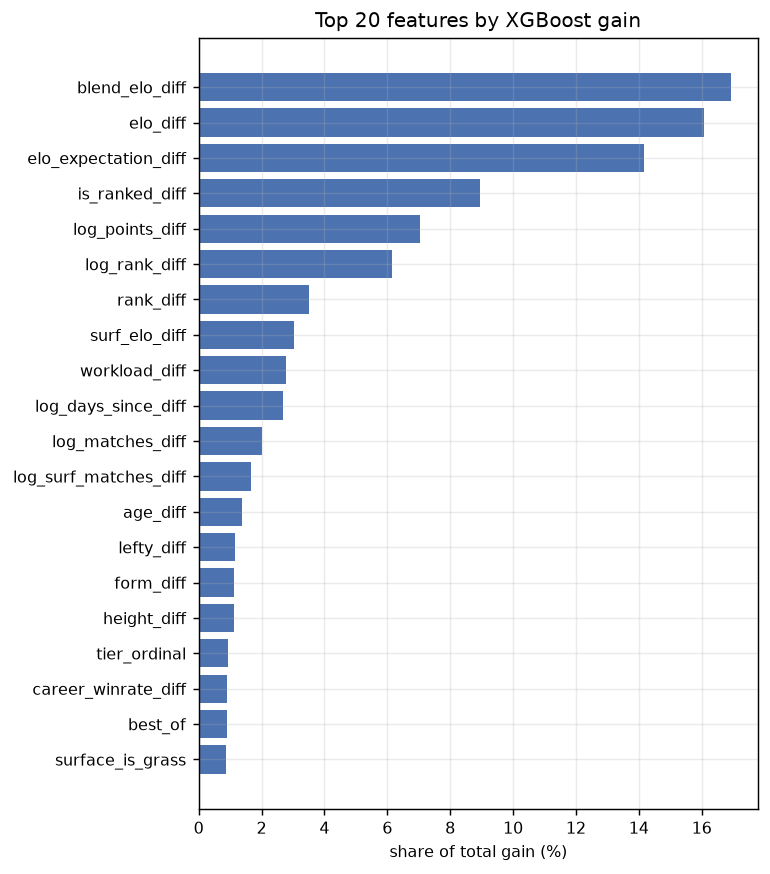

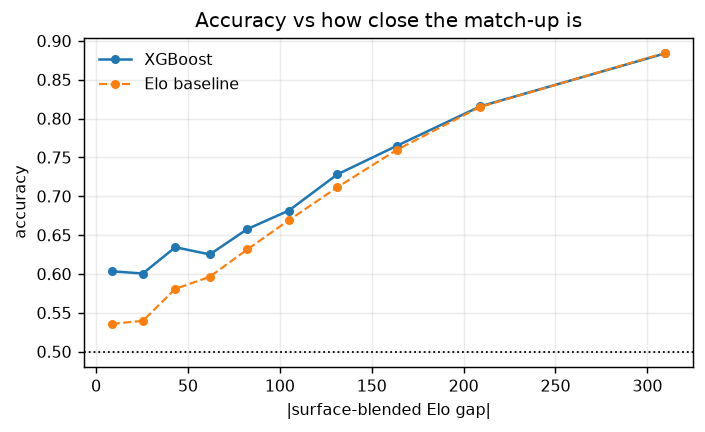

In [11]:
imp = pd.Series(metrics["feature_importance_gain"], name="% of total gain")
display(imp.head(15).to_frame())

reporting.plot_feature_importance(metrics["feature_importance_gain"],
                                  cfg.paths.figures_dir / "feature_importance.png")
reporting.plot_accuracy_by_elo_gap(splits.test.X, splits.test.y, p_test,
                                   cfg.paths.figures_dir / "accuracy_by_elo_gap.png")
display(Image(str(cfg.paths.figures_dir / "feature_importance.png")))
display(Image(str(cfg.paths.figures_dir / "accuracy_by_elo_gap.png")))

---
## 6. Save artifacts

In [12]:
pipeline.save_artifacts(cfg, booster, builder, calibrator, metrics)

for path in sorted(cfg.paths.artifacts_dir.glob("*")):
    if path.is_file():
        print(f"  {path.name:<28s} {path.stat().st_size/1e6:8.1f} MB")

INFO    Artifacts written to artifacts (state 63.0 MB)


  engine_state.pkl                 63.0 MB
  metrics.json                      0.0 MB
  tennis_xgb_model.json             4.1 MB


---
## 7. Predict a future match

`PredictionEngine` rebuilds the feature builder from the saved state and calls
**the same `match_vector` used in training**. That train/serve parity matters:
the previous version hand-wrote the inference vector twice, in two different
cells, and both copies disagreed with the training code. One of them referenced a
`rank_points_diff` column that has never existed, so rank and points were fed to
the model as zeros at prediction time while being real numbers during training.

In [13]:
from tennis_engine.predict import PredictionEngine

engine = PredictionEngine.load(cfg)

for a, b, surface in [
    ("Jannik Sinner", "Carlos Alcaraz", "Hard"),
    ("Jannik Sinner", "Carlos Alcaraz", "Clay"),
    ("Novak Djokovic", "Carlos Alcaraz", "Grass"),
    ("Alexander Zverev", "Daniil Medvedev", "Hard"),
]:
    print(engine.predict_match(a, b, surface=surface, best_of=5))
    print()

INFO    Engine loaded: 28,451 players, 712,282 h2h pairs, state through day 20075


Jannik Sinner vs Carlos Alcaraz (Hard, 2026-08-15)
  Jannik Sinner                 72.9%  (fair odds 1.37)
  Carlos Alcaraz                27.1%  (fair odds 3.69)

Jannik Sinner vs Carlos Alcaraz (Clay, 2026-08-15)
  Jannik Sinner                 45.7%  (fair odds 2.19)
  Carlos Alcaraz                54.3%  (fair odds 1.84)

Novak Djokovic vs Carlos Alcaraz (Grass, 2026-08-15)
  Novak Djokovic                48.2%  (fair odds 2.07)
  Carlos Alcaraz                51.8%  (fair odds 1.93)

Alexander Zverev vs Daniil Medvedev (Hard, 2026-08-15)
  Alexander Zverev              53.6%  (fair odds 1.87)
  Daniil Medvedev               46.4%  (fair odds 2.15)



Surface matters, and it should: the same two players get different probabilities
on clay than on hard. That is the surface-Elo block doing its job.

### Sanity checks a reviewer would ask for

In [14]:
# 1. Order invariance at the API level.
fwd = engine.predict_match("Jannik Sinner", "Carlos Alcaraz", surface="Hard")
rev = engine.predict_match("Carlos Alcaraz", "Jannik Sinner", surface="Hard")
print(f"P(Sinner) forward = {fwd.p1_win_prob:.10f}")
print(f"P(Sinner) reversed = {rev.p2_win_prob:.10f}")
assert abs(fwd.p1_win_prob - rev.p2_win_prob) < 1e-9
print("PASS  identical to 1e-9\n")

# 2. A top player against a journeyman should be a heavy favourite.
lopsided = engine.predict_match("Jannik Sinner", "Zizou Bergs", surface="Hard")
print(lopsided, "\n")

# 3. Player state is inspectable, not a black box.
display(pd.Series(engine.player_card("Carlos Alcaraz", surface="Clay")).to_frame("value"))

P(Sinner) forward = 0.7012847966
P(Sinner) reversed = 0.7012847966
PASS  identical to 1e-9

Jannik Sinner vs Zizou Bergs (Hard, 2026-08-15)
  Jannik Sinner                 95.3%  (fair odds 1.05)
  Zizou Bergs                    4.7%  (fair odds 21.17) 



,value
player,Carlos Alcaraz
player_id,207989
elo,2451.3
elo_clay,2367.7
atp_rank,3
atp_points,7010
matches_played,349
career_win_pct,79.4
clay_win_pct,80.6
last_20_win_pct,75.0


In [15]:
# Current Elo leaderboard, restricted to players active in the last season.
display(engine.elo_leaderboard(top_n=15))
display(engine.elo_leaderboard(top_n=10, surface="Clay"))

,player,elo,surface_elo,matches
0,Jannik Sinner,2598.9,None,432
1,Novak Djokovic,2527.4,None,1378
2,Carlos Alcaraz,2451.3,None,349
3,Rafael Nadal,2390.3,None,1377
4,Alexander Zverev,2372.3,None,755
5,Daniil Medvedev,2340.7,None,722
6,Taylor Fritz,2323.2,None,626
7,Grigor Dimitrov,2301.0,None,905
8,Jack Draper,2287.7,None,294
9,Alex De Minaur,2279.1,None,538


,player,elo,surface_elo,matches
0,Rafael Nadal,2390.3,2414.7,1377
1,Novak Djokovic,2527.4,2391.3,1378
2,Carlos Alcaraz,2451.3,2367.7,349
3,Stefanos Tsitsipas,2245.4,2284.6,695
4,Alexander Zverev,2372.3,2275.0,755
5,Matteo Berrettini,2256.0,2261.6,466
6,Jannik Sinner,2598.9,2236.5,432
7,Casper Ruud,2184.9,2226.3,591
8,Andy Murray,2088.8,2176.2,1095
9,Lorenzo Musetti,2178.4,2155.3,369


---
## 8. Summary of what changed from v1

| Area | Before | After |
|---|---|---|
| Early stopping | on the 2024 **test** set | on a 2023 **validation** season; 2024 untouched |
| `srv_winrate_diff` | identically 0 (regex ate `*_1stWon`/`*_2ndWon`) | real rolling serve efficiency |
| Missing serve data | `NaN`/0.0 pushed into rolling means | excluded from the mean; emitted as `NaN` for XGBoost |
| Surface one-hot | absent keys became `NaN` | true one-hot incl. an explicit `Unknown` |
| Unknown surface | rewritten to `Hard` | kept distinct |
| Order invariance | asserted `mean error < 0.02` | exact by symmetrized prediction (`<1e-9` worst case) |
| Inference features | hand-written twice, both wrong | same `match_vector` as training |
| `height` / `age` at predict time | hard-coded to 0 | resolved from the player directory |
| Calibration | none | validation-fitted, symmetry-preserving |
| Baselines | none | Elo, surface-Elo, ATP rank, coin flip |
| Evaluation rows | every match counted twice | one row per match |
| Tests | none | 57 tests covering leakage, symmetry and I/O |
| Interface | notebook cells only | installable package + CLI |

The CLI does everything this notebook does:

```bash
python -m tennis_engine train
python -m tennis_engine predict "Jannik Sinner" "Carlos Alcaraz" --surface Clay --explain
python -m tennis_engine leaderboard --surface Grass --top 10
python -m tennis_engine card "Novak Djokovic"
```